Using device: cuda
Loading cached model and losses...
Loaded model with 200 training epochs


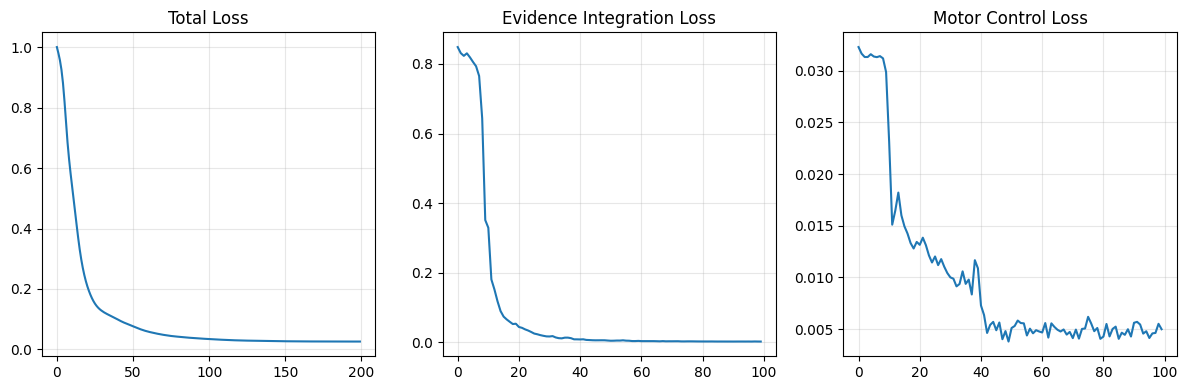

Analyzing your trained model...
Extracting trajectories from trained model...

Analyzing Evidence Region...
Evidence PCA explained variance: [0.87848496 0.08864949 0.01486463]


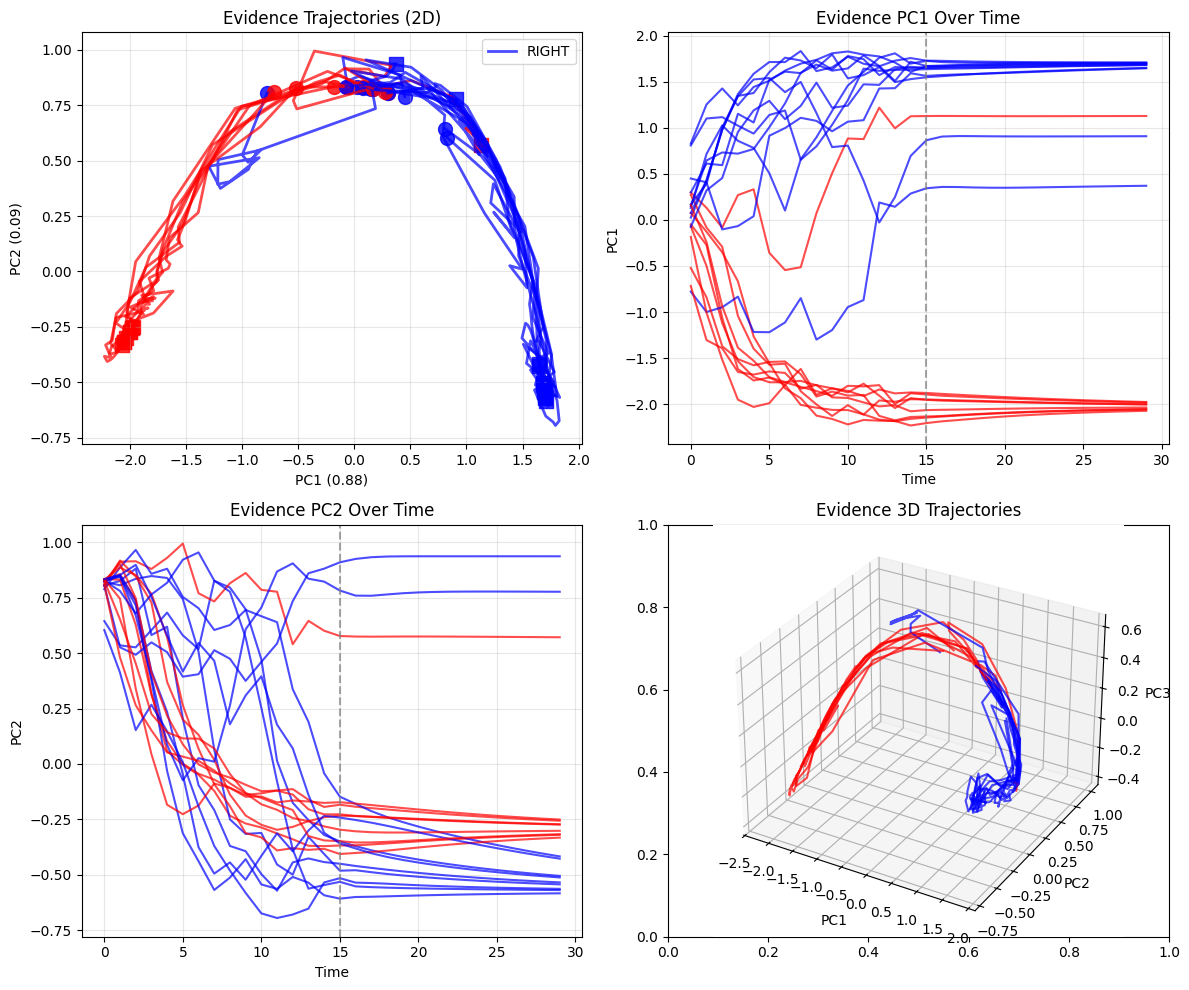


Analyzing Motor Region...
Motor PCA explained variance: [0.3450955  0.32115158 0.20048836]


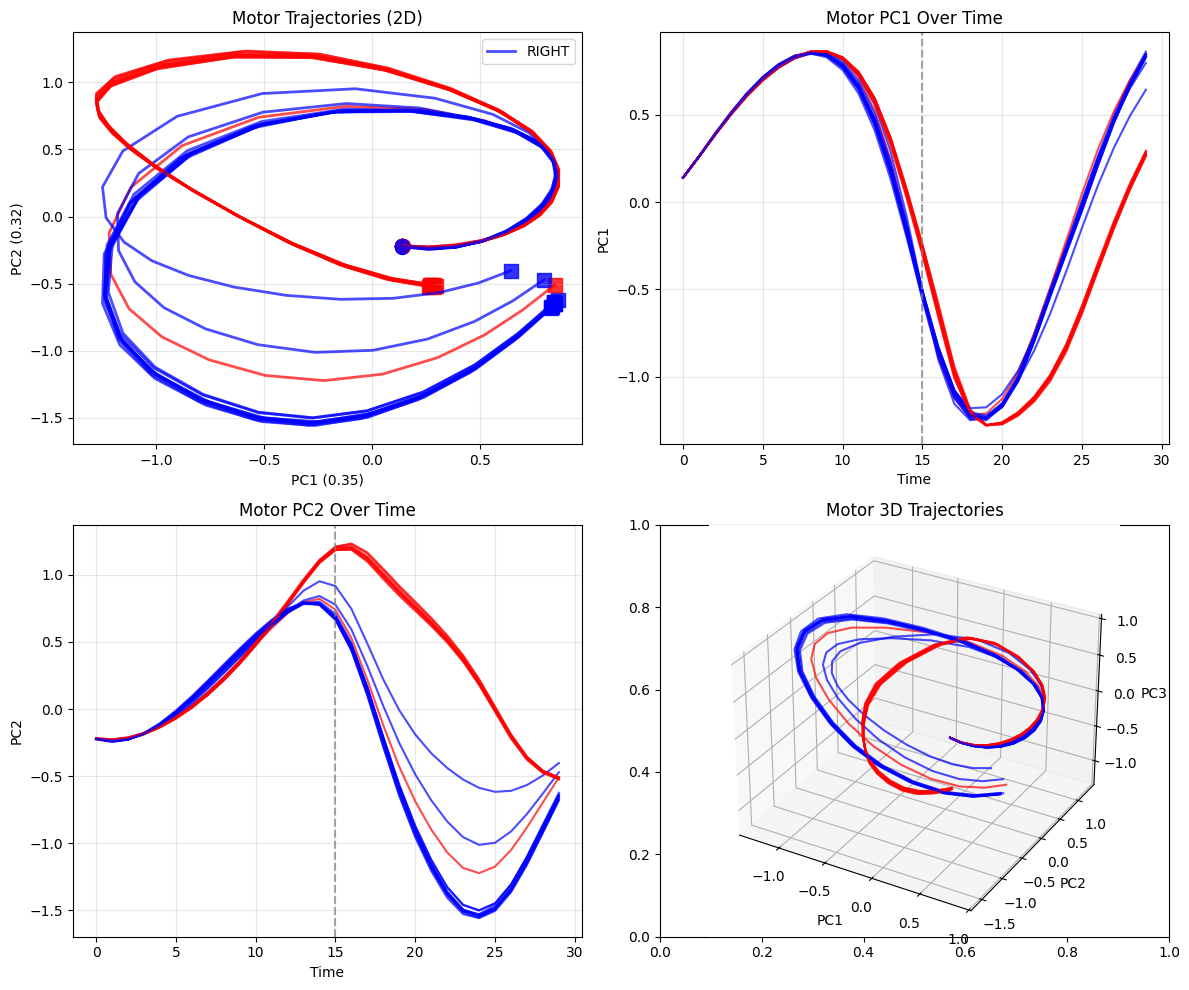


Analyzing Communication...


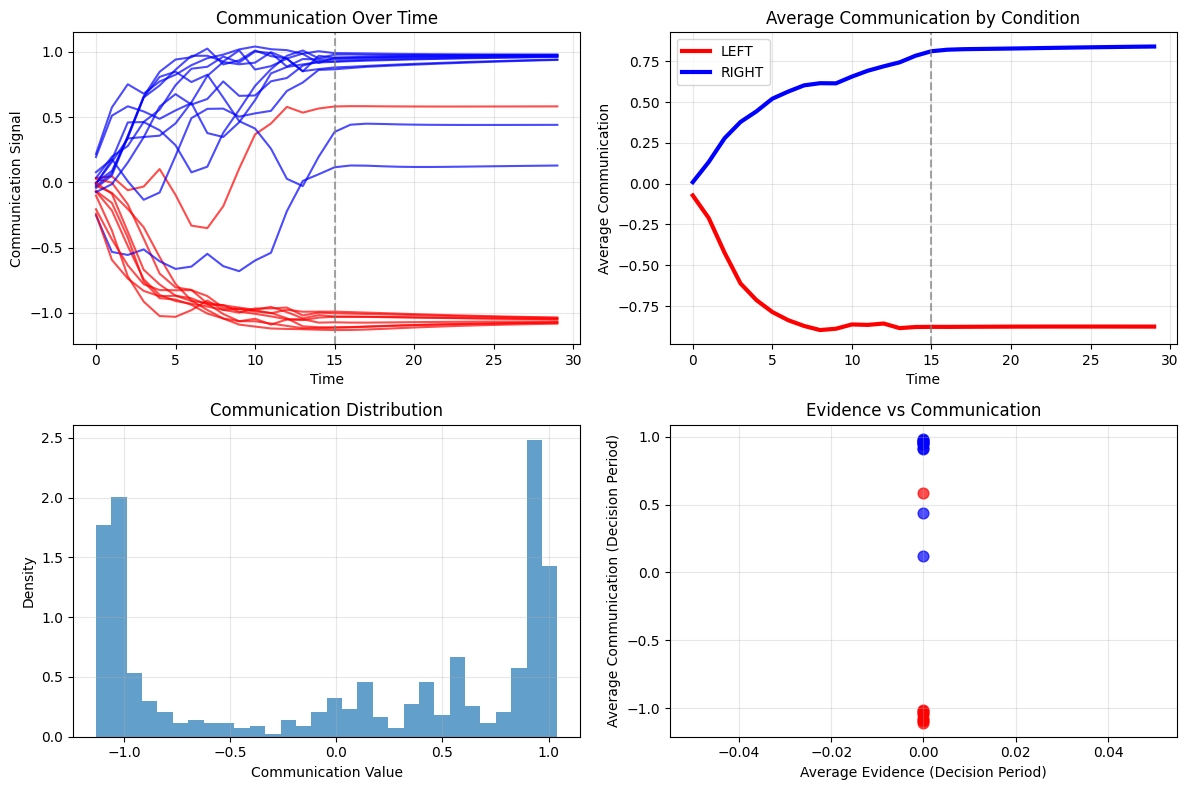

Training complete! Model saved as 'trained_model'


In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import seaborn as sns
import os
import torch



# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Task parameters
SEQUENCE_LENGTH = 30
EVIDENCE_PHASE = 15  # First 40 steps have evidence
RESPONSE_STEP = 29   # Must be correct at step 49
BATCH_SIZE = 128
N_TRIALS = 1000
COHERENCE = 0.8      # Evidence strength
NOISE_LEVEL = 0.5    # Evidence noise

def generate_task_data(batch_size, sequence_length, coherence=0.3, noise_level=0.5):
    """Generate evidence integration + reaching task data"""
    
    # Random target direction for each trial (0=LEFT, 1=RIGHT)
    targets = torch.randint(0, 2, (batch_size,), device=device)
    
    # Evidence streams (first 40 timesteps)
    evidence = torch.zeros(batch_size, sequence_length, 2, device=device)
    evidence[:, :EVIDENCE_PHASE, 0] = (1 - targets.float()).unsqueeze(1) * coherence + \
                                      torch.randn(batch_size, EVIDENCE_PHASE, device=device) * noise_level
    evidence[:, :EVIDENCE_PHASE, 1] = targets.float().unsqueeze(1) * coherence + \
                                      torch.randn(batch_size, EVIDENCE_PHASE, device=device) * noise_level
    
    # True evidence integration (teaching signal for Region 1)
    true_integration = torch.cumsum(evidence[:, :, 1] - evidence[:, :, 0], dim=1)
    true_integration = torch.tanh(true_integration)  # Bounded integration
    
    # Target reach trajectories (teaching signal for Region 2)
    target_positions = torch.zeros(batch_size, sequence_length, 2, device=device)
    target_velocities = torch.zeros(batch_size, sequence_length, 2, device=device)
    
    for i in range(batch_size):
        if targets[i] == 0:  # LEFT reach
            target_positions[i, :, 0] = -1.0  # x = -1
            target_positions[i, :, 1] = 0.0   # y = 0
        else:  # RIGHT reach  
            target_positions[i, :, 0] = 1.0   # x = 1
            target_positions[i, :, 1] = 0.0   # y = 0
    
    # Smooth velocity trajectories (start moving after evidence phase)
    for t in range(EVIDENCE_PHASE, sequence_length):
        progress = (t - EVIDENCE_PHASE) / (sequence_length - EVIDENCE_PHASE)
        smooth_vel = 0.5 * np.sin(np.pi * progress) if progress < 1.0 else 0.0
        
        for i in range(batch_size):
            if targets[i] == 0:  # LEFT
                target_velocities[i, t, 0] = -smooth_vel
            else:  # RIGHT
                target_velocities[i, t, 0] = smooth_vel
    
    return {
        'evidence': evidence,
        'targets': targets,
        'true_integration': true_integration,
        'target_positions': target_positions,
        'target_velocities': target_velocities
    }

class MultiRegionRNN(nn.Module):
    def __init__(self, evidence_hidden=64, motor_hidden=64):
        super().__init__()
        
        # Region 1: Evidence Integrator
        self.evidence_rnn = nn.LSTM(
            input_size=2,  # [evidence_left, evidence_right]
            hidden_size=evidence_hidden,
            batch_first=True
        )
        self.evidence_output = nn.Linear(evidence_hidden, 1)  # Integrated evidence
        
        # Region 2: Motor Controller  
        self.motor_rnn = nn.LSTM(
            input_size=3,  # [communication_from_R1, position_x, position_y]
            hidden_size=motor_hidden,
            batch_first=True
        )
        self.motor_output = nn.Linear(motor_hidden, 2)  # [velocity_x, velocity_y]
        
        # Communication layer (Region 1 → Region 2)
        self.communication = nn.Linear(evidence_hidden, 1)
        
        self.evidence_hidden_size = evidence_hidden
        self.motor_hidden_size = motor_hidden
        
    def forward(self, evidence_input):
        batch_size, seq_len, _ = evidence_input.shape
        
        # Initialize motor state
        motor_position = torch.zeros(batch_size, seq_len, 2, device=evidence_input.device)
        motor_velocity = torch.zeros(batch_size, seq_len, 2, device=evidence_input.device)
        
        # Storage for outputs
        evidence_outputs = []
        motor_outputs = []
        communications = []
        
        # Initialize hidden states
        evidence_hidden = (torch.zeros(1, batch_size, self.evidence_hidden_size, device=evidence_input.device),
                          torch.zeros(1, batch_size, self.evidence_hidden_size, device=evidence_input.device))
        motor_hidden = (torch.zeros(1, batch_size, self.motor_hidden_size, device=evidence_input.device),
                       torch.zeros(1, batch_size, self.motor_hidden_size, device=evidence_input.device))
        
        for t in range(seq_len):
            # Region 1: Evidence Integration
            evidence_out, evidence_hidden = self.evidence_rnn(
                evidence_input[:, t:t+1, :], evidence_hidden
            )
            integrated_evidence = self.evidence_output(evidence_out.squeeze(1))
            evidence_outputs.append(integrated_evidence)
            
            # Communication: Region 1 → Region 2
            comm_signal = self.communication(evidence_out.squeeze(1))
            communications.append(comm_signal)
            
            # Region 2: Motor Control
            motor_input = torch.cat([
                comm_signal,
                motor_position[:, t, :]
            ], dim=1).unsqueeze(1)
            
            motor_out, motor_hidden = self.motor_rnn(motor_input, motor_hidden)
            velocity_output = torch.tanh(self.motor_output(motor_out.squeeze(1)))
            motor_outputs.append(velocity_output)
            
            # Update motor state for next timestep
            if t < seq_len - 1:
                motor_velocity[:, t+1, :] = velocity_output
                motor_position[:, t+1, :] = motor_position[:, t, :] + velocity_output * 0.1
        
        return {
            'evidence_integration': torch.stack(evidence_outputs, dim=1),
            'motor_velocity': torch.stack(motor_outputs, dim=1),
            'communication': torch.stack(communications, dim=1),
            'motor_position': motor_position
        }

def train_multi_region_rnn():
    """Train multi-region RNN efficiently"""
    
    # Initialize model
    model = MultiRegionRNN(evidence_hidden=64, motor_hidden=64).to(device)
    model = torch.compile(model)
    optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.OneCycleLR(
        optimizer, max_lr=5e-3, epochs=100, steps_per_epoch=N_TRIALS//BATCH_SIZE
    )
    
    # Training loop
    losses = []
    evidence_losses = []
    motor_losses = []
    
    for epoch in tqdm(range(100), desc="Training Multi-Region RNN"):
        epoch_loss = 0
        epoch_evidence_loss = 0
        epoch_motor_loss = 0
        
        for batch_idx in range(N_TRIALS // BATCH_SIZE):
            # Generate batch
            batch_data = generate_task_data(BATCH_SIZE, SEQUENCE_LENGTH)
            
            # Forward pass
            outputs = model(batch_data['evidence'])
            
            # Loss computation
            # Region 1 loss: Evidence integration accuracy
            evidence_loss = nn.MSELoss()(
                outputs['evidence_integration'], 
                batch_data['true_integration'].unsqueeze(-1)
            )
            
            # Region 2 loss: Motor control accuracy  
            motor_loss = nn.MSELoss()(
                outputs['motor_velocity'],
                batch_data['target_velocities']
            )
            
            # Combined loss
            total_loss = evidence_loss + motor_loss
            
            # Backward pass
            optimizer.zero_grad()
            total_loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            scheduler.step()
            
            epoch_loss += total_loss.item()
            epoch_evidence_loss += evidence_loss.item()
            epoch_motor_loss += motor_loss.item()
        
        # Record losses
        avg_loss = epoch_loss / (N_TRIALS // BATCH_SIZE)
        avg_evidence_loss = epoch_evidence_loss / (N_TRIALS // BATCH_SIZE)
        avg_motor_loss = epoch_motor_loss / (N_TRIALS // BATCH_SIZE)
        
        losses.append(avg_loss)
        evidence_losses.append(avg_evidence_loss)
        motor_losses.append(avg_motor_loss)
        
        if epoch % 20 == 0:
            print(f"Epoch {epoch}: Total={avg_loss:.4f}, Evidence={avg_evidence_loss:.4f}, Motor={avg_motor_loss:.4f}")
    
    return model, losses, evidence_losses, motor_losses

def analyze_trained_model(model):
    """Analyze the trained multi-region RNN"""
    model.eval()
    
    with torch.no_grad():
        # Generate test data
        test_data = generate_task_data(5, SEQUENCE_LENGTH, coherence=0.5)
        outputs = model(test_data['evidence'])
        
        # Plot results
        fig, axes = plt.subplots(2, 3, figsize=(15, 10))
        
        # Evidence integration
        for trial in range(3):
            axes[0, trial].plot(outputs['evidence_integration'][trial].cpu(), 
                              label='RNN Integration', linewidth=2)
            axes[0, trial].plot(test_data['true_integration'][trial].cpu(), 
                              label='True Integration', linestyle='--')
            axes[0, trial].axvline(x=EVIDENCE_PHASE, color='red', linestyle=':', alpha=0.7)
            axes[0, trial].set_title(f'Trial {trial+1}: Evidence Integration')
            axes[0, trial].legend()
            axes[0, trial].grid(True, alpha=0.3)
        
        # Motor control
        for trial in range(3):
            axes[1, trial].plot(outputs['motor_velocity'][trial, :, 0].cpu(), 
                              label='RNN Velocity X', linewidth=2)
            axes[1, trial].plot(test_data['target_velocities'][trial, :, 0].cpu(), 
                              label='Target Velocity X', linestyle='--')
            axes[1, trial].axvline(x=EVIDENCE_PHASE, color='red', linestyle=':', alpha=0.7)
            axes[1, trial].set_title(f'Trial {trial+1}: Motor Control')
            axes[1, trial].legend()
            axes[1, trial].grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
        
        # Communication analysis
        plt.figure(figsize=(12, 4))
        for trial in range(3):
            plt.subplot(1, 3, trial+1)
            plt.plot(outputs['communication'][trial].cpu(), linewidth=2)
            plt.axvline(x=EVIDENCE_PHASE, color='red', linestyle=':', alpha=0.7)
            plt.title(f'Communication Signal (Trial {trial+1})')
            plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

def generate_task_data(batch_size, sequence_length, coherence=0.3, noise_level=0.5):
    """Generate evidence integration + reaching task data"""
    
    # Random target direction for each trial (0=LEFT, 1=RIGHT)
    targets = torch.randint(0, 2, (batch_size,), device=device)
    
    # Evidence streams (first 15 timesteps)
    evidence = torch.zeros(batch_size, sequence_length, 2, device=device)
    evidence[:, :EVIDENCE_PHASE, 0] = (1 - targets.float()).unsqueeze(1) * coherence + \
                                      torch.randn(batch_size, EVIDENCE_PHASE, device=device) * noise_level
    evidence[:, :EVIDENCE_PHASE, 1] = targets.float().unsqueeze(1) * coherence + \
                                      torch.randn(batch_size, EVIDENCE_PHASE, device=device) * noise_level
    
    # True evidence integration (teaching signal for Region 1)
    true_integration = torch.cumsum(evidence[:, :, 1] - evidence[:, :, 0], dim=1)
    true_integration = torch.tanh(true_integration)  # Bounded integration
    
    # Target reach trajectories (teaching signal for Region 2)
    target_positions = torch.zeros(batch_size, sequence_length, 2, device=device)
    target_velocities = torch.zeros(batch_size, sequence_length, 2, device=device)
    
    for i in range(batch_size):
        if targets[i] == 0:  # LEFT reach
            target_positions[i, :, 0] = -1.0  # x = -1
            target_positions[i, :, 1] = 0.0   # y = 0
        else:  # RIGHT reach  
            target_positions[i, :, 0] = 1.0   # x = 1
            target_positions[i, :, 1] = 0.0   # y = 0
    
    # Smooth velocity trajectories (start moving after evidence phase)
    for t in range(EVIDENCE_PHASE, sequence_length):
        progress = (t - EVIDENCE_PHASE) / (sequence_length - EVIDENCE_PHASE)
        smooth_vel = 0.5 * np.sin(np.pi * progress) if progress < 1.0 else 0.0
        
        for i in range(batch_size):
            if targets[i] == 0:  # LEFT
                target_velocities[i, t, 0] = -smooth_vel
            else:  # RIGHT
                target_velocities[i, t, 0] = smooth_vel
    
    return {
        'evidence': evidence,
        'targets': targets,
        'true_integration': true_integration,
        'target_positions': target_positions,
        'target_velocities': target_velocities
    }

def extract_trajectories(model, n_trials=10, noise_scale=0):
    """Extract hidden state trajectories from trained model"""
    model.eval()
    
    evidence_states = []
    motor_states = []
    communications = []
    trial_info = []
    
    with torch.no_grad():
        for trial_idx in range(n_trials):
            batch_data = generate_task_data(1, SEQUENCE_LENGTH)  # Single trial
            
            # Run model and collect hidden states
            evidence_hiddens = []
            motor_hiddens = []
            comms = []
            
            evidence_hidden = (torch.zeros(1, 1, model.evidence_hidden_size, device=device),
                              torch.zeros(1, 1, model.evidence_hidden_size, device=device))
            motor_hidden = (torch.zeros(1, 1, model.motor_hidden_size, device=device),
                           torch.zeros(1, 1, model.motor_hidden_size, device=device))
            
            motor_position = torch.zeros(1, 2, device=device)
            
            for t in range(SEQUENCE_LENGTH):
                # Evidence region
                evidence_out, evidence_hidden = model.evidence_rnn(
                    batch_data['evidence'][:, t:t+1, :], evidence_hidden
                )
                noisy_evidence = evidence_hidden[0] + noise_scale * torch.randn_like(evidence_hidden[0])
                evidence_hiddens.append(noisy_evidence.squeeze().cpu().numpy())
                
                # Communication
                comm = model.communication(evidence_out.squeeze(1))
                noisy_comm = comm + noise_scale * torch.randn_like(comm)
                comms.append(noisy_comm.cpu().numpy())
                
                # Motor region
                motor_input = torch.cat([comm, motor_position], dim=1).unsqueeze(1)
                motor_out, motor_hidden = model.motor_rnn(motor_input, motor_hidden)
                noisy_motor = motor_hidden[0] + noise_scale * torch.randn_like(motor_hidden[0])

                motor_hiddens.append(noisy_motor.squeeze().cpu().numpy())
                
                # Update motor position
                velocity = torch.tanh(model.motor_output(motor_out.squeeze(1)))
                motor_position = motor_position + velocity * 0.1
            
            evidence_states.append(np.array(evidence_hiddens))
            motor_states.append(np.array(motor_hiddens))
            communications.append(np.array(comms).squeeze())
            trial_info.append({
                'target': batch_data['targets'].item(),
                'evidence': batch_data['evidence'].squeeze().cpu().numpy(),
                'true_integration': batch_data['true_integration'].squeeze().cpu().numpy()
            })
    
    return {
        'evidence_states': np.array(evidence_states),  # [n_trials, time, hidden_dim]
        'motor_states': np.array(motor_states),
        'communications': np.array(communications),
        'trial_info': trial_info
    }

def plot_trajectories_pca(trajectories, region_name='Evidence'):
    """Plot trajectories in PCA space"""
    states = trajectories['evidence_states'] if region_name == 'Evidence' else trajectories['motor_states']
    n_trials, n_time, n_dim = states.shape
    
    # Fit PCA on all data
    all_states = states.reshape(-1, n_dim)
    pca = PCA(n_components=min(3, n_dim))
    pca.fit(all_states)
    
    print(f"{region_name} PCA explained variance: {pca.explained_variance_ratio_[:3]}")
    
    # Transform trajectories
    states_pca = np.zeros((n_trials, n_time, pca.n_components_))
    for trial in range(n_trials):
        states_pca[trial] = pca.transform(states[trial])
    
    # Plot
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    
    # 2D trajectory plot colored by target
    for trial in range(n_trials):
        target = trajectories['trial_info'][trial]['target']
        color = 'red' if target == 0 else 'blue'
        label = 'LEFT' if target == 0 else 'RIGHT'
        
        if trial == 0 or (trial == 1 and target == 1):  # Add labels only once per condition
            axes[0,0].plot(states_pca[trial, :, 0], states_pca[trial, :, 1], 
                          color=color, alpha=0.7, linewidth=2, label=label)
        else:
            axes[0,0].plot(states_pca[trial, :, 0], states_pca[trial, :, 1], 
                          color=color, alpha=0.7, linewidth=2)
        
        # Mark start and end
        axes[0,0].scatter(states_pca[trial, 0, 0], states_pca[trial, 0, 1], 
                         color=color, s=100, marker='o', alpha=0.8)
        axes[0,0].scatter(states_pca[trial, -1, 0], states_pca[trial, -1, 1], 
                         color=color, s=100, marker='s', alpha=0.8)
    
    axes[0,0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2f})')
    axes[0,0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2f})')
    axes[0,0].set_title(f'{region_name} Trajectories (2D)')
    axes[0,0].legend()
    axes[0,0].grid(True, alpha=0.3)
    
    # PC1 over time
    for trial in range(n_trials):
        target = trajectories['trial_info'][trial]['target']
        color = 'red' if target == 0 else 'blue'
        axes[0,1].plot(states_pca[trial, :, 0], color=color, alpha=0.7)
    
    axes[0,1].axvline(x=EVIDENCE_PHASE, color='gray', linestyle='--', alpha=0.7)
    axes[0,1].set_xlabel('Time')
    axes[0,1].set_ylabel('PC1')
    axes[0,1].set_title(f'{region_name} PC1 Over Time')
    axes[0,1].grid(True, alpha=0.3)
    
    # PC2 over time
    for trial in range(n_trials):
        target = trajectories['trial_info'][trial]['target']
        color = 'red' if target == 0 else 'blue'
        axes[1,0].plot(states_pca[trial, :, 1], color=color, alpha=0.7)
    
    axes[1,0].axvline(x=EVIDENCE_PHASE, color='gray', linestyle='--', alpha=0.7)
    axes[1,0].set_xlabel('Time')
    axes[1,0].set_ylabel('PC2')
    axes[1,0].set_title(f'{region_name} PC2 Over Time')
    axes[1,0].grid(True, alpha=0.3)
    
    # 3D plot if available
    if pca.n_components_ >= 3:
        ax = fig.add_subplot(224, projection='3d')
        for trial in range(n_trials):
            target = trajectories['trial_info'][trial]['target']
            color = 'red' if target == 0 else 'blue'
            ax.plot(states_pca[trial, :, 0], states_pca[trial, :, 1], states_pca[trial, :, 2], 
                   color=color, alpha=0.7)
        
        ax.set_xlabel('PC1')
        ax.set_ylabel('PC2')
        ax.set_zlabel('PC3')
        ax.set_title(f'{region_name} 3D Trajectories')
    
    plt.tight_layout()
    plt.show()
    
    return pca, states_pca

def plot_communication_analysis(trajectories):
    """Analyze communication between regions"""
    comms = trajectories['communications']  # [n_trials, time]
    
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    
    # Communication over time by condition
    for trial in range(len(trajectories['trial_info'])):
        target = trajectories['trial_info'][trial]['target']
        color = 'red' if target == 0 else 'blue'
        axes[0,0].plot(comms[trial], color=color, alpha=0.7)
    
    axes[0,0].axvline(x=EVIDENCE_PHASE, color='gray', linestyle='--', alpha=0.7)
    axes[0,0].set_xlabel('Time')
    axes[0,0].set_ylabel('Communication Signal')
    axes[0,0].set_title('Communication Over Time')
    axes[0,0].grid(True, alpha=0.3)
    
    # Average communication by condition
    left_trials = [i for i, info in enumerate(trajectories['trial_info']) if info['target'] == 0]
    right_trials = [i for i, info in enumerate(trajectories['trial_info']) if info['target'] == 1]
    
    if left_trials:
        avg_comm_left = np.mean(comms[left_trials], axis=0)
        axes[0,1].plot(avg_comm_left, color='red', linewidth=3, label='LEFT')
    
    if right_trials:
        avg_comm_right = np.mean(comms[right_trials], axis=0)
        axes[0,1].plot(avg_comm_right, color='blue', linewidth=3, label='RIGHT')
    
    axes[0,1].axvline(x=EVIDENCE_PHASE, color='gray', linestyle='--', alpha=0.7)
    axes[0,1].set_xlabel('Time')
    axes[0,1].set_ylabel('Average Communication')
    axes[0,1].set_title('Average Communication by Condition')
    axes[0,1].legend()
    axes[0,1].grid(True, alpha=0.3)
    
    # Communication distribution
    all_comms = comms.flatten()
    axes[1,0].hist(all_comms, bins=30, alpha=0.7, density=True)
    axes[1,0].set_xlabel('Communication Value')
    axes[1,0].set_ylabel('Density')
    axes[1,0].set_title('Communication Distribution')
    axes[1,0].grid(True, alpha=0.3)
    
    # Evidence vs Communication scatter
    for trial in range(len(trajectories['trial_info'])):
        evidence = trajectories['trial_info'][trial]['evidence'][:, 0]  # Evidence signal
        target = trajectories['trial_info'][trial]['target']
        color = 'red' if target == 0 else 'blue'
        
        # Use evidence in second half (decision period)
        evidence_decision = np.mean(evidence[EVIDENCE_PHASE:])
        comm_decision = np.mean(comms[trial, EVIDENCE_PHASE:])
        
        axes[1,1].scatter(evidence_decision, comm_decision, color=color, alpha=0.7, s=60)
    
    axes[1,1].set_xlabel('Average Evidence (Decision Period)')
    axes[1,1].set_ylabel('Average Communication (Decision Period)')
    axes[1,1].set_title('Evidence vs Communication')
    axes[1,1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

def analyze_model_behavior(model):
    """Complete analysis of trained model"""
    print("Extracting trajectories from trained model...")
    trajectories = extract_trajectories(model, n_trials=20)
    
    print("\nAnalyzing Evidence Region...")
    pca_evidence, states_pca_evidence = plot_trajectories_pca(trajectories, 'Evidence')
    
    print("\nAnalyzing Motor Region...")
    pca_motor, states_pca_motor = plot_trajectories_pca(trajectories, 'Motor')
    
    print("\nAnalyzing Communication...")
    plot_communication_analysis(trajectories)
    
    return trajectories, pca_evidence, pca_motor


import os
import torch


def load_trained_model():
    """Load cached model and training data if available"""
    cache_dir = "cache/decision_motor_rnn"
    model_path = os.path.join(cache_dir, "model.pt")
    losses_path = os.path.join(cache_dir, "losses.pt")
    
    if os.path.exists(model_path) and os.path.exists(losses_path):
        print("Loading cached model and losses...")
        
        # Load model
        model = MultiRegionRNN(evidence_hidden=64, motor_hidden=64).to(device)
        state_dict = torch.load(model_path, map_location=device)
        
        # Remove '_orig_mod.' prefix if present
        state_dict = {k.replace('_orig_mod.', ''): v for k, v in state_dict.items()}
        
        model.load_state_dict(state_dict)
        
        # Load losses
        losses_data = torch.load(losses_path, map_location=device)
        
        print(f"Loaded model with {len(losses_data['losses'])} training epochs")
        return model, losses_data['losses'], losses_data['evidence_losses'], losses_data['motor_losses'], True
    
    return None, None, None, None, False
    

def save_trained_model(model, losses, evidence_losses, motor_losses):
    """Save model and training data to cache"""
    cache_dir = "cache/decision_motor_rnn"
    os.makedirs(cache_dir, exist_ok=True)
    
    # Save model
    model_path = os.path.join(cache_dir, "model.pt")
    torch.save(model.state_dict(), model_path)
    
    # Save losses
    losses_path = os.path.join(cache_dir, "losses.pt")
    losses_data = {
        'losses': losses,
        'evidence_losses': evidence_losses,
        'motor_losses': motor_losses
    }
    torch.save(losses_data, losses_path)
    
    print(f"Saved model and losses to {cache_dir}")


trained_model, losses, evidence_losses, motor_losses, loaded = load_trained_model()
# loaded = False
if not loaded:
    # Train if not cached
    print("No cached model found. Training Multi-Region RNN...")
    trained_model, losses, evidence_losses, motor_losses = train_multi_region_rnn()
    # Save after training
    save_trained_model(trained_model, losses, evidence_losses, motor_losses)
        
# Plot training curves
plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.plot(losses)
plt.title('Total Loss')
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 2)
plt.plot(evidence_losses)
plt.title('Evidence Integration Loss')
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 3)
plt.plot(motor_losses)
plt.title('Motor Control Loss')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Run the analysis on your trained model
print("Analyzing your trained model...")
trajectories, pca_evidence, pca_motor = analyze_model_behavior(trained_model)

print("Training complete! Model saved as 'trained_model'")

In [6]:
import torch
import torch.nn as nn
import torch.optim as optim
from tqdm import tqdm

class MRgnODE_DynamicComm(nn.Module):
    def __init__(self, N=4, input_dim=2, tau_regions=0.01, hidden_dim = 64, tau_comm=0.05, num_regions=2, comm_dim=16):
        super().__init__()
        self.num_regions = num_regions
        self.region_dim = N // num_regions
        self.comm_dim = comm_dim
        self.tau_regions = tau_regions
        self.tau_comm = tau_comm
        
        # Total state: regions + communication channels
        self.num_comm_channels = num_regions * (num_regions - 1)  # Bidirectional
        self.N_regions = N
        self.N_total = N + self.num_comm_channels * comm_dim
        
        
        region_input_dim = self.region_dim + input_dim
        
        # Region dynamics networks
        self.region_flow_net = nn.Sequential(
            nn.Linear(region_input_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, self.region_dim)
        )
        
        self.region_gate_net = nn.Sequential(
            nn.Linear(region_input_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, self.region_dim),
            nn.Sigmoid()
        )
        
        # Communication dynamics networks
        comm_input_dim = self.region_dim + comm_dim  # Source region + current comm state
        
        self.comm_flow_net = nn.Sequential(
            nn.Linear(comm_input_dim, hidden_dim//2),
            nn.Tanh(),
            nn.Linear(hidden_dim//2, hidden_dim//2),
            nn.Tanh(),
            nn.Linear(hidden_dim//2, comm_dim)
        )
        
        self.comm_gate_net = nn.Sequential(
            nn.Linear(comm_input_dim, hidden_dim//2),
            nn.Tanh(),
            nn.Linear(hidden_dim//2, comm_dim),
            nn.Sigmoid()
        )
        
        # Communication-to-region coupling
        self.comm_to_region = nn.Sequential(
            nn.Linear(comm_dim, self.region_dim),
            nn.Tanh(),
            nn.Linear(self.region_dim, self.region_dim)
        )
        
        # Learnable asymmetric weights for each communication direction
        self.comm_signs = nn.Parameter(torch.ones(self.num_comm_channels))  # Can learn positive/negative
        
        self.apply(self._init_weights)
        
    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            nn.init.xavier_uniform_(module.weight, gain=0.5)
            if module.bias is not None:
                nn.init.zeros_(module.bias)
    
    def partition_state(self, h):
        """Partition hidden state into regions and communication channels"""
        batch_size = h.shape[0]
        h_regions = h[:, :self.N_regions]  # [batch, N_regions]
        h_comm = h[:, self.N_regions:]     # [batch, num_comm_channels * comm_dim]
        
        # Reshape regions: [batch, num_regions, region_dim]
        h_regions = h_regions.view(batch_size, self.num_regions, self.region_dim)
        
        # Reshape communication: [batch, num_comm_channels, comm_dim]
        h_comm = h_comm.view(batch_size, self.num_comm_channels, self.comm_dim)
        
        return h_regions, h_comm
    
    def get_comm_channel_idx(self, source_region, target_region):
        """Get communication channel index for source->target"""
        # Map (source, target) pairs to channel indices
        # For 2 regions: (0,1)->0, (1,0)->1
        if source_region == target_region:
            return None
        
        # Channel indexing: each source region has (num_regions-1) outgoing channels
        channel_idx = source_region * (self.num_regions - 1)
        target_offset = target_region if target_region < source_region else target_region - 1
        return channel_idx + target_offset
    
    def compute_region_dynamics(self, h_regions, x, h_comm):
        """Compute region dynamics with communication input"""
        batch_size = h_regions.shape[0]
        flow_regions = []
        gate_regions = []
        
        for region_idx in range(self.num_regions):
            # Get region state and input
            h_region = h_regions[:, region_idx, :]  # [batch, region_dim]
            x_region = x[:, region_idx, :]  # [batch, input_dim]
            
            # Compute communication input to this region
            comm_input = torch.zeros_like(h_region)
            for source_region in range(self.num_regions):
                if source_region != region_idx:
                    channel_idx = self.get_comm_channel_idx(source_region, region_idx)
                    if channel_idx is not None:
                        comm_state = h_comm[:, channel_idx, :]  # [batch, comm_dim]
                        comm_effect = self.comm_to_region(comm_state)
                        # Apply learnable sign for asymmetric effects
                        comm_input += self.comm_signs[channel_idx] * comm_effect
            
            # Region dynamics
            hx_region = torch.cat([h_region + comm_input, x_region], dim=-1)
            flow_region = self.region_flow_net(hx_region)
            gate_region = self.region_gate_net(hx_region)
            
            flow_regions.append(flow_region)
            gate_regions.append(gate_region)
        
        flow = torch.stack(flow_regions, dim=1).view(batch_size, -1)
        gate = torch.stack(gate_regions, dim=1).view(batch_size, -1)
        h_regions_flat = h_regions.view(batch_size, -1)
        
        h_regions_dot = gate * (-h_regions_flat + flow) / self.tau_regions
        return h_regions_dot
    
    def compute_comm_dynamics(self, h_regions, h_comm):
        """Compute communication channel dynamics"""
        batch_size = h_regions.shape[0]
        comm_flows = []
        comm_gates = []
        
        for channel_idx in range(self.num_comm_channels):
            # Determine source region for this channel
            source_region = channel_idx // (self.num_regions - 1)
            
            # Get source region state and current communication state
            h_source = h_regions[:, source_region, :]  # [batch, region_dim]
            h_comm_current = h_comm[:, channel_idx, :]  # [batch, comm_dim]
            
            # Communication dynamics
            comm_input = torch.cat([h_source, h_comm_current], dim=-1)
            flow_comm = self.comm_flow_net(comm_input)
            gate_comm = self.comm_gate_net(comm_input)
            
            comm_flows.append(flow_comm)
            comm_gates.append(gate_comm)
        
        flow = torch.stack(comm_flows, dim=1)  # [batch, num_comm_channels, comm_dim]
        gate = torch.stack(comm_gates, dim=1)  # [batch, num_comm_channels, comm_dim]
        
        h_comm_dot = gate * (-h_comm + flow) / self.tau_comm
        return h_comm_dot.view(batch_size, -1)  # Flatten for concatenation
    
    def get_outputs(self, h):
        """Return raw region states as [batch, regions, region_dim]"""
        h_regions, _ = self.partition_state(h)
        return h_regions
        
    def forward(self, h, x, timestep=0):
        """
        h: [batch, N_total] - regions + communication channels
        x: [batch, num_regions, input_dim] - region-specific inputs  
        """
        # Partition state
        h_regions, h_comm = self.partition_state(h)
        
        # Compute dynamics for each partition
        h_regions_dot = self.compute_region_dynamics(h_regions, x, h_comm)
        h_comm_dot = self.compute_comm_dynamics(h_regions, h_comm)
        
        # Concatenate dynamics
        h_dot = torch.cat([h_regions_dot, h_comm_dot], dim=-1)
        
        # Return communication norms for tracking
        comm_norm = torch.norm(h_comm)
        
        return h_dot, comm_norm 
        
def load_mrgnodes_data(cache_dir = "cache/mr_gnode_fit_dmotor_rnn", model = None):
    """Load cached MR-gnODE model and data if available"""
    
    model_path = os.path.join(cache_dir, "mrgnodes_model.pt")
    data_path = os.path.join(cache_dir, "mrgnodes_data.pt")
    
    if os.path.exists(model_path) and os.path.exists(data_path):
        print("Loading cached MR-gnODE model and data...")
        
        # Load data
        data = torch.load(data_path, map_location=device, weights_only=False)
        rnn_trajectories = data['rnn_trajectories']
        reconstruction_data = data['reconstruction_data']
        losses = data['losses']
        
        # Load model
        if not model:
            model = MRgnODE_DynamicComm(N=128, input_dim=64, hidden_dim=32, num_regions=2, comm_dim=8)
        model = model.to(device)
        model.load_state_dict(torch.load(model_path, map_location=device))
        
        print(f"Loaded MR-gnODE model with {len(losses)} training epochs")
        return model, rnn_trajectories, reconstruction_data, losses, True
    
    return None, None, None, None, False

def save_mrgnodes_data(model, rnn_trajectories, reconstruction_data, losses,  cache_dir = "cache/mr_gnode_fit_dmotor_rnn"):
    """Save MR-gnODE model and data to cache"""
   
    os.makedirs(cache_dir, exist_ok=True)
    
    # Save model
    model_path = os.path.join(cache_dir, "mrgnodes_model.pt")
    torch.save(model.state_dict(), model_path)
    
    # Save data
    data_path = os.path.join(cache_dir, "mrgnodes_data.pt")
    data = {
        'rnn_trajectories': rnn_trajectories,
        'reconstruction_data': reconstruction_data,
        'losses': losses
    }
    torch.save(data, data_path)
    
    print(f"Saved MR-gnODE model and data to {cache_dir}")


def save_mprslds_data(rslds, trajectories, posterior, elbos, data_mean, data_std,
                      K, D_vec, N_vec, data_flat, preds, cache_dir="cache/mprslds_fit_dmotor_rnn"):
    """Save MP-RSLDS model and data to cache"""
    import os
    import pickle
    import numpy as np
    
    os.makedirs(cache_dir, exist_ok=True)
    
    # Save model
    model_path = os.path.join(cache_dir, "mprslds_model.pkl")
    with open(model_path, 'wb') as f:
        pickle.dump(rslds, f)
    
    # Save posterior
    posterior_path = os.path.join(cache_dir, "mprslds_posterior.pkl")
    with open(posterior_path, 'wb') as f:
        pickle.dump(posterior, f)
    
    # Save data and predictions
    data_path = os.path.join(cache_dir, "mprslds_data.npz")
    np.savez(data_path,
             trajectories_evidence=trajectories['evidence_states'],
             trajectories_motor=trajectories['motor_states'],
             data_flat=data_flat,
             predictions=preds,
             data_mean=data_mean,
             data_std=data_std,
             elbos=elbos,
             K=K,
             D_vec=D_vec,
             N_vec=N_vec)
    
    print(f"Saved MP-RSLDS to {cache_dir}")

def load_mprslds_data(cache_dir="cache/mprslds_fit_dmotor_rnn"):
    """Load cached MP-RSLDS model and data if available"""
    import os
    import pickle
    import numpy as np
    
    model_path = os.path.join(cache_dir, "mprslds_model.pkl")
    posterior_path = os.path.join(cache_dir, "mprslds_posterior.pkl")
    data_path = os.path.join(cache_dir, "mprslds_data.npz")
    
    if os.path.exists(model_path) and os.path.exists(posterior_path) and os.path.exists(data_path):
        print("Loading cached MP-RSLDS model and data...")
        
        # Load model
        with open(model_path, 'rb') as f:
            rslds = pickle.load(f)
        
        # Load posterior
        with open(posterior_path, 'rb') as f:
            posterior = pickle.load(f)
        
        # Load data
        data = np.load(data_path)
        trajectories = {
            'evidence_states': data['trajectories_evidence'],
            'motor_states': data['trajectories_motor']
        }
        data_flat = data['data_flat']
        predictions = data['predictions']
        data_mean = data['data_mean']
        data_std = data['data_std']
        elbos = data['elbos']
        K = int(data['K'])
        D_vec = list(data['D_vec'])
        N_vec = list(data['N_vec'])
        
        print(f"Loaded MP-RSLDS with K={K}, {len(elbos)} training iterations")
        
        return {
            'rslds': rslds,
            'trajectories': trajectories,
            'posterior': posterior,
            'predictions': predictions,
            'data_flat': data_flat,
            'data_mean': data_mean,
            'data_std': data_std,
            'elbos': elbos,
            'K': K,
            'D_vec': D_vec,
            'N_vec': N_vec
        }
    
    return None

def extract_rnn_multi_region_data(trained_rnn, n_trials=200, noise_scale=0):
    """Extract multi-region trajectories - SAME as original but with normalization"""
    trained_rnn.eval()
    all_trajectories = []
    
    with torch.no_grad():
        for trial in range(n_trials):
            batch_data = generate_task_data(1, SEQUENCE_LENGTH)
            
            evidence_hidden = (torch.zeros(1, 1, trained_rnn.evidence_hidden_size, device=device),
                              torch.zeros(1, 1, trained_rnn.evidence_hidden_size, device=device))
            motor_hidden = (torch.zeros(1, 1, trained_rnn.motor_hidden_size, device=device),
                           torch.zeros(1, 1, trained_rnn.motor_hidden_size, device=device))
            
            trial_trajectory = []
            motor_position = torch.zeros(1, 2, device=device)
            
            for t in range(SEQUENCE_LENGTH):
                evidence_out, evidence_hidden = trained_rnn.evidence_rnn(
                    batch_data['evidence'][:, t:t+1, :], evidence_hidden
                )
                evidence_state = evidence_hidden[0].squeeze(0)
                noisy_evidence = evidence_state + noise_scale * torch.randn_like(evidence_state)

                comm = trained_rnn.communication(evidence_out.squeeze(1))
                noisy_comm = comm + noise_scale * torch.randn_like(comm)

                motor_input = torch.cat([comm, motor_position], dim=1).unsqueeze(1)
                motor_out, motor_hidden = trained_rnn.motor_rnn(motor_input, motor_hidden)
                motor_state = motor_hidden[0].squeeze(0)
                noisy_motor = motor_state + noise_scale * torch.randn_like(motor_state)

                velocity = torch.tanh(trained_rnn.motor_output(motor_out.squeeze(1)))
                motor_position = motor_position + velocity * 0.1
                
                combined_state = torch.stack([noisy_evidence, noisy_motor], dim=1)
                trial_trajectory.append(combined_state)
            
            trial_trajectory = torch.stack(trial_trajectory, dim=1)
            all_trajectories.append(trial_trajectory.squeeze(0))
    
    trajectories = torch.stack(all_trajectories, dim=0)
    
    # ONLY ADDITION: Normalize to prevent NaNs
    mean = trajectories.mean(dim=(0, 1), keepdim=True)
    std = trajectories.std(dim=(0, 1), keepdim=True) + 1e-6
    trajectories = (trajectories - mean) / std
    
    return trajectories

In [7]:
# Cell 1: Load Models and Setup
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import os

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Load trained RNN
rnn_model, _, _, _, rnn_loaded = load_trained_model()
if not rnn_loaded:
    raise ValueError("Need trained RNN model first")

# Load MR-gnODE if available
mrgnodes_model, mrgnodes_trajectories, mrgnodes_reconstruction, mrgnodes_losses, mrgnodes_loaded = load_mrgnodes_data()

# Load MP-RSLDS if available  
mprslds_data = load_mprslds_data()
mprslds_loaded = mprslds_data is not None

print(f"RNN loaded: {rnn_loaded}")
print(f"MR-gnODE loaded: {mrgnodes_loaded}")
print(f"MP-RSLDS loaded: {mprslds_loaded}")

Loading cached model and losses...
Loaded model with 200 training epochs
Loading cached MR-gnODE model and data...
Loaded MR-gnODE model with 300 training epochs
Loading cached MP-RSLDS model and data...
Loaded MP-RSLDS with K=5, 51 training iterations
RNN loaded: True
MR-gnODE loaded: True
MP-RSLDS loaded: True


In [13]:
# Cell 2: Extract Data and Run Models
def extract_unified_trajectories(rnn_model, n_trials=200, noise_scale=0):
    """Extract trajectories in format compatible with both models"""
    rnn_model.eval()
    all_trajectories = []
    
    with torch.no_grad():
        for trial in range(n_trials):
            batch_data = generate_task_data(1, SEQUENCE_LENGTH)
            
            evidence_hidden = (torch.zeros(1, 1, rnn_model.evidence_hidden_size, device=device),
                              torch.zeros(1, 1, rnn_model.evidence_hidden_size, device=device))
            motor_hidden = (torch.zeros(1, 1, rnn_model.motor_hidden_size, device=device),
                           torch.zeros(1, 1, rnn_model.motor_hidden_size, device=device))
            
            trial_trajectory = []
            motor_position = torch.zeros(1, 2, device=device)
            
            for t in range(SEQUENCE_LENGTH):
                evidence_out, evidence_hidden = rnn_model.evidence_rnn(
                    batch_data['evidence'][:, t:t+1, :], evidence_hidden
                )
                evidence_state = evidence_hidden[0].squeeze(0)
                noisy_evidence = evidence_state + noise_scale * torch.randn_like(evidence_state)

                comm = rnn_model.communication(evidence_out.squeeze(1))
                motor_input = torch.cat([comm, motor_position], dim=1).unsqueeze(1)
                motor_out, motor_hidden = rnn_model.motor_rnn(motor_input, motor_hidden)
                motor_state = motor_hidden[0].squeeze(0)
                noisy_motor = motor_state + noise_scale * torch.randn_like(motor_state)

                velocity = torch.tanh(rnn_model.motor_output(motor_out.squeeze(1)))
                motor_position = motor_position + velocity * 0.1
                
                # Stack regions for multi-region format
                combined_state = torch.stack([noisy_evidence, noisy_motor], dim=1)
                trial_trajectory.append(combined_state)
            
            trial_trajectory = torch.stack(trial_trajectory, dim=1)
            all_trajectories.append(trial_trajectory.squeeze(0))
    
    trajectories = torch.stack(all_trajectories, dim=0)
    
    # REMOVE NORMALIZATION - let each model handle its own normalization
    return trajectories

# Extract test trajectories (no normalization)
test_trajectories = extract_unified_trajectories(rnn_model, n_trials=100)
print(f"Test trajectories shape: {test_trajectories.shape}")

# Run MR-gnODE if loaded
mrgnodes_results = {}
if mrgnodes_loaded:
    print("Running MR-gnODE...")
    mrgnodes_model.eval()
    
    # MR-gnODE: Apply its own normalization
    mean = test_trajectories.mean(dim=(0, 1), keepdim=True)
    std = test_trajectories.std(dim=(0, 1), keepdim=True) + 1e-6
    test_trajectories_norm = (test_trajectories - mean) / std
    
    test_evidence = test_trajectories_norm[:, :, 0, :].cpu().numpy()
    test_motor = test_trajectories_norm[:, :, 1, :].cpu().numpy()
    test_targets = np.stack([test_evidence, test_motor], axis=2)
    
    dt = 0.01
    all_preds = []
    
    with torch.no_grad():
        for trial_idx in range(test_trajectories.shape[0]):
            trial_target = torch.tensor(test_targets[trial_idx], dtype=torch.float32, device=device)
            seq_len = trial_target.shape[0]
            
            h = torch.zeros(1, mrgnodes_model.N_total, device=device)
            outputs = []
            
            for t in range(seq_len):
                x_t = trial_target[t:t+1]
                h_dot, _ = mrgnodes_model(h, x_t, timestep=t)
                h = h + dt * h_dot
                outputs.append(mrgnodes_model.get_outputs(h))
            
            pred = torch.stack(outputs, dim=1).squeeze(0)
            all_preds.append(pred)
    
    preds = torch.stack(all_preds).cpu().numpy()
    mrgnodes_results['reconstruction'] = torch.tensor(preds)
    
    # Metrics on normalized data
    mse_total = np.mean((test_targets - preds) ** 2)
    r2_total = 1 - np.var(test_targets - preds) / np.var(test_targets)
    
    mrgnodes_results.update({'mse': mse_total, 'r2': r2_total})
    print(f"MR-gnODE Total: MSE={mse_total:.6f}, R²={r2_total:.4f}")

# Run MP-RSLDS if loaded
mprslds_results = {}
if mprslds_loaded:
    print("Running MP-RSLDS...")
    rslds = mprslds_data['rslds']
    data_mean = mprslds_data['data_mean']
    data_std = mprslds_data['data_std']
    
    # MP-rSLDS: Use RAW (unnormalized) test data, then apply MP-rSLDS normalization
    test_evidence = test_trajectories[:, :, 0, :].cpu().numpy()
    test_motor = test_trajectories[:, :, 1, :].cpu().numpy()
    test_data = np.concatenate([test_evidence, test_motor], axis=2)
    
    N_total = test_data.shape[-1]
    print(f"Using RAW data - N_total: {N_total}")
    print(f"Test data range: [{test_data.min():.3f}, {test_data.max():.3f}]")
    print(f"Training stats range: mean=[{data_mean.min():.3f}, {data_mean.max():.3f}], std=[{data_std.min():.3f}, {data_std.max():.3f}]")
    
    # Apply MP-rSLDS normalization (single normalization)
    test_data_norm = (test_data - data_mean) / data_std
    test_data_flat = test_data_norm.reshape(-1, N_total).astype(np.float64)
    
    print("Generating MP-rSLDS predictions...")
    
    try:
        test_elbos, test_posterior = rslds.fit(
            test_data_flat,
            method="laplace_em",
            variational_posterior="structured_meanfield",
            continuous_optimizer='newton',
            initialize=False,
            num_iters=5,
            alpha=0.25
        )
        
        test_preds = rslds.smooth(test_posterior.mean_continuous_states[0], test_data_flat)
        test_preds_trials = test_preds.reshape(test_data.shape[0], -1, N_total)
        test_preds_orig = test_preds_trials * data_std + data_mean
        
        mprslds_results['predictions'] = test_preds_orig
        
        # Compute metrics
        mse_total_rslds = np.mean((test_data - test_preds_orig) ** 2)
        r2_total_rslds = 1 - np.var(test_data - test_preds_orig) / np.var(test_data)
        
        mprslds_results.update({'mse': mse_total_rslds, 'r2': r2_total_rslds})
        print(f"MP-rSLDS Total: MSE={mse_total_rslds:.6f}, R²={r2_total_rslds:.4f}")
        
    except Exception as e:
        print(f"MP-RSLDS prediction failed: {e}")
        mprslds_results['error'] = str(e)

Test trajectories shape: torch.Size([100, 30, 2, 64])
Running MR-gnODE...
MR-gnODE Total: MSE=0.002994, R²=0.9970
Running MP-RSLDS...
Using RAW data - N_total: 128
Test data range: [-0.987, 0.986]
Training stats range: mean=[-0.285, 0.280], std=[0.035, 0.445]
Generating MP-rSLDS predictions...


  0%|          | 0/5 [00:00<?, ?it/s]

MP-rSLDS Total: MSE=0.036750, R²=0.0572


In [14]:
# Cell 2: Extract Data and Run Models

# Extract test trajectories using the SAME function used for MP-rSLDS training
test_trajectories_dict = extract_trajectories(rnn_model, n_trials=100, noise_scale=0.03)

# Prepare data exactly like MP-rSLDS training
evidence_data = test_trajectories_dict['evidence_states']  # [n_trials, time, 64]
motor_data = test_trajectories_dict['motor_states']        # [n_trials, time, 64]

# Concatenate into single observation matrix (same as training)
test_data = np.concatenate([evidence_data, motor_data], axis=2)  # [n_trials, time, 128]
print(f"Test data shape: {test_data.shape}")

# Convert to tensor format for MR-gnODE
test_trajectories = torch.from_numpy(np.stack([evidence_data, motor_data], axis=2)).float()  # [trials, time, 2, 64]

# Run MR-gnODE if loaded
mrgnodes_results = {}
if mrgnodes_loaded:
    print("Running MR-gnODE...")
    mrgnodes_model.eval()
    
    # Prepare test data in the format MR-gnODE expects
    test_evidence = test_trajectories[:, :, 0, :].cpu().numpy()
    test_motor = test_trajectories[:, :, 1, :].cpu().numpy()
    test_targets = np.stack([test_evidence, test_motor], axis=2)
    
    dt = 0.01
    all_preds = []
    
    with torch.no_grad():
        for trial_idx in range(test_trajectories.shape[0]):
            trial_target = torch.tensor(test_targets[trial_idx], dtype=torch.float32, device=device)
            seq_len = trial_target.shape[0]
            
            h = torch.zeros(1, mrgnodes_model.N_total, device=device)
            outputs = []
            
            for t in range(seq_len):
                x_t = trial_target[t:t+1]
                h_dot, _ = mrgnodes_model(h, x_t, timestep=t)
                h = h + dt * h_dot
                outputs.append(mrgnodes_model.get_outputs(h))
            
            pred = torch.stack(outputs, dim=1).squeeze(0)
            all_preds.append(pred)
    
    preds = torch.stack(all_preds).cpu().numpy()
    mrgnodes_results['reconstruction'] = torch.tensor(preds)
    
    # Separate regions for detailed analysis
    true_ev = test_targets[:, :, 0, :]
    true_mt = test_targets[:, :, 1, :]
    pred_ev = preds[:, :, 0, :]
    pred_mt = preds[:, :, 1, :]
    
    mse_ev = np.mean((true_ev - pred_ev) ** 2)
    mse_mt = np.mean((true_mt - pred_mt) ** 2)
    mse_total = np.mean((test_targets - preds) ** 2)
    
    var_ev = np.var(true_ev)
    var_mt = np.var(true_mt)
    var_total = np.var(test_targets)
    
    r2_ev = 1 - np.var(true_ev - pred_ev) / var_ev
    r2_mt = 1 - np.var(true_mt - pred_mt) / var_mt
    r2_total = 1 - np.var(test_targets - preds) / var_total
    
    mrgnodes_results.update({
        'mse': mse_total, 'r2': r2_total,
        'mse_evidence': mse_ev, 'mse_motor': mse_mt,
        'r2_evidence': r2_ev, 'r2_motor': r2_mt
    })
    
    print(f"MR-gnODE Evidence: MSE={mse_ev:.6f}, R²={r2_ev:.4f}")
    print(f"MR-gnODE Motor:    MSE={mse_mt:.6f}, R²={r2_mt:.4f}")
    print(f"MR-gnODE Total:    MSE={mse_total:.6f}, R²={r2_total:.4f}")

# Run MP-RSLDS if loaded
mprslds_results = {}
if mprslds_loaded:
    print("Running MP-RSLDS...")
    rslds = mprslds_data['rslds']
    data_mean = mprslds_data['data_mean']
    data_std = mprslds_data['data_std']
    
    # Use EXACT same normalization as training
    print(f"Test data range before norm: [{test_data.min():.3f}, {test_data.max():.3f}]")
    test_data_norm = (test_data - data_mean) / data_std
    print(f"Test data range after norm: [{test_data_norm.min():.3f}, {test_data_norm.max():.3f}]")
    
    N_total = test_data.shape[-1]
    test_data_flat = test_data_norm.reshape(-1, N_total).astype(np.float64)
    
    print("Generating MP-rSLDS predictions...")
    
    try:
        # EXACT same parameters as training
        test_elbos, test_posterior = rslds.fit(
            test_data_flat,
            method="laplace_em",
            variational_posterior="structured_meanfield",
            continuous_optimizer='newton',
            initialize=False,  # Use existing parameters
            num_iters=5,       # Just infer states
            alpha=0.25
        )
        
        # Get predictions
        test_preds = rslds.smooth(test_posterior.mean_continuous_states[0], test_data_flat)
        test_preds_trials = test_preds.reshape(test_data.shape[0], -1, N_total)
        
        # Denormalize predictions
        test_preds_orig = test_preds_trials * data_std + data_mean
        
        # Split regions exactly like training
        pred_ev_rslds = test_preds_orig[:, :, :64]   # Evidence region
        pred_mt_rslds = test_preds_orig[:, :, 64:]   # Motor region
        true_ev_rslds = evidence_data  # Use original evidence_data
        true_mt_rslds = motor_data     # Use original motor_data
        
        # MSE
        mse_ev_rslds = np.mean((true_ev_rslds - pred_ev_rslds) ** 2)
        mse_mt_rslds = np.mean((true_mt_rslds - pred_mt_rslds) ** 2)
        mse_total_rslds = np.mean((test_data - test_preds_orig) ** 2)
        
        # R²
        var_ev_rslds = np.var(true_ev_rslds)
        var_mt_rslds = np.var(true_mt_rslds)
        var_total_rslds = np.var(test_data)
        
        r2_ev_rslds = 1 - np.var(true_ev_rslds - pred_ev_rslds) / var_ev_rslds
        r2_mt_rslds = 1 - np.var(true_mt_rslds - pred_mt_rslds) / var_mt_rslds
        r2_total_rslds = 1 - np.var(test_data - test_preds_orig) / var_total_rslds
        
        mprslds_results.update({
            'mse': mse_total_rslds, 'r2': r2_total_rslds,
            'mse_evidence': mse_ev_rslds, 'mse_motor': mse_mt_rslds,
            'r2_evidence': r2_ev_rslds, 'r2_motor': r2_mt_rslds,
            'predictions': test_preds_orig
        })
        
        print(f"MP-rSLDS Evidence: MSE={mse_ev_rslds:.6f}, R²={r2_ev_rslds:.4f}")
        print(f"MP-rSLDS Motor:    MSE={mse_mt_rslds:.6f}, R²={r2_mt_rslds:.4f}")
        print(f"MP-rSLDS Total:    MSE={mse_total_rslds:.6f}, R²={r2_total_rslds:.4f}")
        
    except Exception as e:
        print(f"MP-RSLDS prediction failed: {e}")
        mprslds_results['error'] = str(e)

Test data shape: (100, 30, 128)
Running MR-gnODE...
MR-gnODE Evidence: MSE=0.007356, R²=0.8683
MR-gnODE Motor:    MSE=0.008165, R²=0.7030
MR-gnODE Total:    MSE=0.007760, R²=0.8119
Running MP-RSLDS...
Test data range before norm: [-1.052, 1.018]
Test data range after norm: [-12.862, 18.580]
Generating MP-rSLDS predictions...


  0%|          | 0/5 [00:00<?, ?it/s]

MP-rSLDS Evidence: MSE=0.034047, R²=0.3873
MP-rSLDS Motor:    MSE=0.014705, R²=0.4598
MP-rSLDS Total:    MSE=0.024376, R²=0.4101
